[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ReevesJustin/data-driven-reloading/blob/main/notebooks/01_The_Biggest_Lie_in_Reloading_Testing.ipynb)

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/ReevesJustin/data-driven-reloading/main?filepath=notebooks/01_The_Biggest_Lie_in_Reloading_Testing.ipynb)

Time to complete: 10-15 minutes

# The Biggest Lie in Reloading Testing

## Goal: Visually prove small samples mislead

**Simple simulation:** Same exact load (fixed true SD = 12 fps). Generate 1,000 shots.
Then repeatedly pull random 3-, 5-, 10-, or 30-shot strings. Plot their SDs.
**Interactive slider:** Change sample size → watch how often you get **"magical" ** single-digit SD by *pure chance*.
**Key takeaway:** "Getting a low SD with less than 30 shots proves almost nothing."
Repeat for group sizes: Show how **3×5-shot groups** can look amazing even from a mediocre rifle.

## Simulating Velocity Standard Deviation

This code creates a **fake rifle** with a true SD of 15 fps (like really good factory ammo). We generate 10,000 virtual shots, then pull random samples of 3, 5, 10, or 30 shots to see how their SDs vary. **SD** is how spread out the speeds are. Like how consistent your shots are.

In [1]:
# Imports and setup
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display

# Set random seed for reproducibility
np.random.seed(42)

# True parameters for the simulation
true_mean_velocity = 2700  # fps
true_sd_velocity = 15      # fps

# Generate a large population of shots (10,000 shots)
population_velocities = np.random.normal(true_mean_velocity, true_sd_velocity, 10000)

# Function to sample velocities and compute SD
def sample_sd(n_shots):
    sample = np.random.choice(population_velocities, n_shots, replace=False)
    return np.std(sample, ddof=1)  # Sample standard deviation

# Simulate many samples for different sizes
sample_sizes = [3, 5, 10, 30]
n_simulations = 1000

sd_distributions = {}
for n in sample_sizes:
    sds = [sample_sd(n) for _ in range(n_simulations)]
    sd_distributions[n] = sds

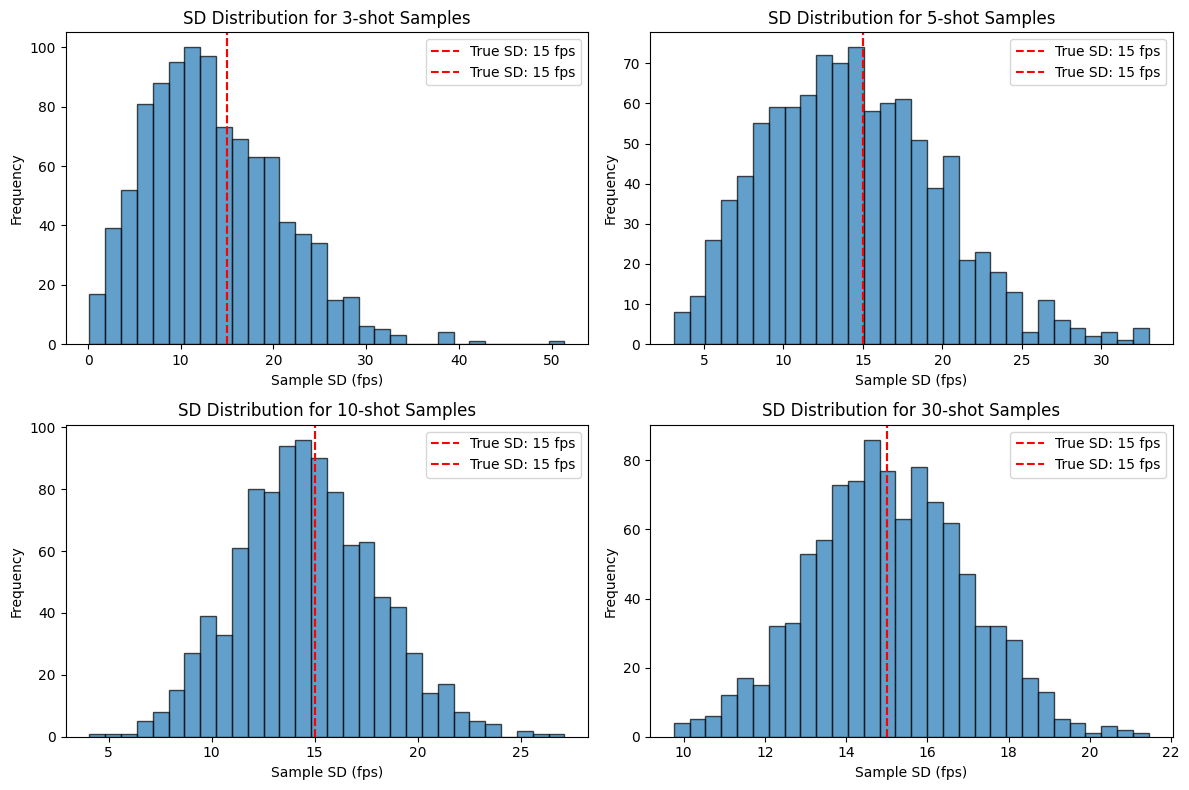

In [2]:
# Cell 2: Plot SD distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, n in enumerate(sample_sizes):
    ax = axes[i]
    ax.hist(sd_distributions[n], bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(true_sd_velocity, color='red', linestyle='--', label=f'True SD: {true_sd_velocity} fps')
    ax.axvline(true_sd_velocity, color='red', linestyle='--', label=f'True SD: {true_sd_velocity} fps')
    ax.set_title(f'SD Distribution for {n}-shot Samples')
    ax.set_xlabel('Sample SD (fps)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

**Interpretation:** This graph shows the distribution of sample standard deviations (SD) for different shot counts from the same rifle. The red line marks the true SD (15 fps). Notice how smaller samples (3, 5 shots) produce highly variable SDs, often much lower than the true value by chance. Larger samples (30 shots) cluster closer to the truth, making them more reliable for detecting real differences in load precision.

In [3]:
# Calculate percentages below true SD
for n in sample_sizes:
    count_below = sum(sd < true_sd_velocity for sd in sd_distributions[n])
    percentage = (count_below / n_simulations) * 100
    print(f'For {n}-shot samples: {percentage:.1f}% have SD below true SD ({true_sd_velocity} fps)')


For 3-shot samples: 62.8% have SD below true SD (15 fps)
For 5-shot samples: 57.0% have SD below true SD (15 fps)
For 10-shot samples: 56.2% have SD below true SD (15 fps)
For 30-shot samples: 50.3% have SD below true SD (15 fps)


In [4]:
# Cell 3: Interactive slider for sample size
def plot_sd_distribution(n):
    sds = [sample_sd(n) for _ in range(n_simulations)]
    plt.figure(figsize=(8, 6))
    plt.hist(sds, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(true_sd_velocity, color='red', linestyle='--', label=f'True SD: {true_sd_velocity} fps')
    plt.axvline(true_sd_velocity, color='red', linestyle='--', label=f'True SD: {true_sd_velocity} fps')
    plt.title(f'SD Distribution for {n}-shot Samples')
    plt.xlabel('Sample SD (fps)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# Create slider widget
slider = widgets.IntSlider(value=10, min=3, max=30, step=1, description='Sample Size:')
widgets.interactive(plot_sd_distribution, n=slider)

interactive(children=(IntSlider(value=10, description='Sample Size:', max=30, min=3), Output()), _dom_classes=…

**Key Takeaway:** **Getting a low SD with less than 30 shots proves almost nothing.**

In [5]:
# Cell 4: Simulation for group sizes
# True dispersion: let's say sigma = 0.5 MOA at 100 yards, but for simplicity, use inches
# Assume group center at (0,0), each shot normal(0, sigma) in x and y
true_group_sigma = 0.5  # inches at 100 yards (about 0.5 MOA)

# Generate population of shot positions
population_shots_x = np.random.normal(0, true_group_sigma, 10000)
population_shots_y = np.random.normal(0, true_group_sigma, 10000)

# Function to compute group size (extreme spread: max - min distance)
def compute_group_size(shots_x, shots_y):
    # Extreme spread: max distance between any two points
    points = np.column_stack((shots_x, shots_y))
    distances = [np.linalg.norm(p1 - p2) for i, p1 in enumerate(points) for p2 in points[i+1:]]
    return max(distances) if distances else 0

# Function to sample a group and compute size
def sample_group_size(n_shots):
    indices = np.random.choice(len(population_shots_x), n_shots, replace=False)
    group_x = population_shots_x[indices]
    group_y = population_shots_y[indices]
    return compute_group_size(group_x, group_y)

# Simulate many 3-shot and 5-shot groups
n_groups = 1000
group_sizes_3 = [sample_group_size(3) for _ in range(n_groups)]

group_data_5 = []
for _ in range(n_groups):
    indices = np.random.choice(len(population_shots_x), 5, replace=False)
    group_x = population_shots_x[indices]
    group_y = population_shots_y[indices]
    size = compute_group_size(group_x, group_y)
    group_data_5.append((size, group_x, group_y))
group_sizes_5 = [d[0] for d in group_data_5]

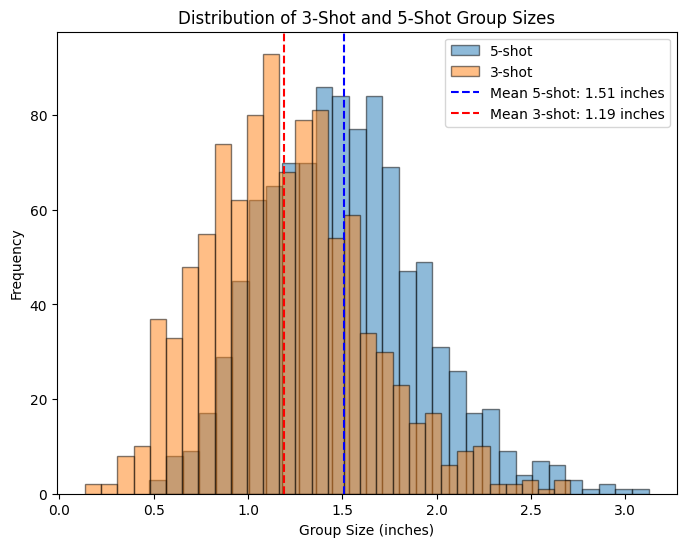

In [6]:
# Cell 5: Plot group size distribution for 3-shot and 5-shot groups
plt.figure(figsize=(8, 6))
plt.hist(group_sizes_5, bins=30, alpha=0.5, label='5-shot', edgecolor='black')
plt.hist(group_sizes_3, bins=30, alpha=0.5, label='3-shot', edgecolor='black')
plt.axvline(np.mean(group_sizes_5), color='blue', linestyle='--', label=f'Mean 5-shot: {np.mean(group_sizes_5):.2f} inches')
plt.axvline(np.mean(group_sizes_3), color='red', linestyle='--', label=f'Mean 3-shot: {np.mean(group_sizes_3):.2f} inches')
plt.title('Distribution of 3-Shot and 5-Shot Group Sizes')
plt.xlabel('Group Size (inches)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**Interpretation:** This histogram compares group size distributions for 3-shot vs. 5-shot groups from a rifle with true 1.5 MOA precision. The 3-shot groups show more extreme variation, with many appearing much tighter than the true capability. The mean group sizes are smaller than expected due to sampling bias, and 5-shot groups are more consistent but still variable. Use this to understand why small groups can mislead you into thinking your rifle/load is better than it is.

- A surprising number of "one-hole" groups and sub-half MOA groups show up for a true 1.5 MOA rifle.
- Even when 1000 3-shot groups are fired the mean group size is notably smaller than the true precision of the rifle.

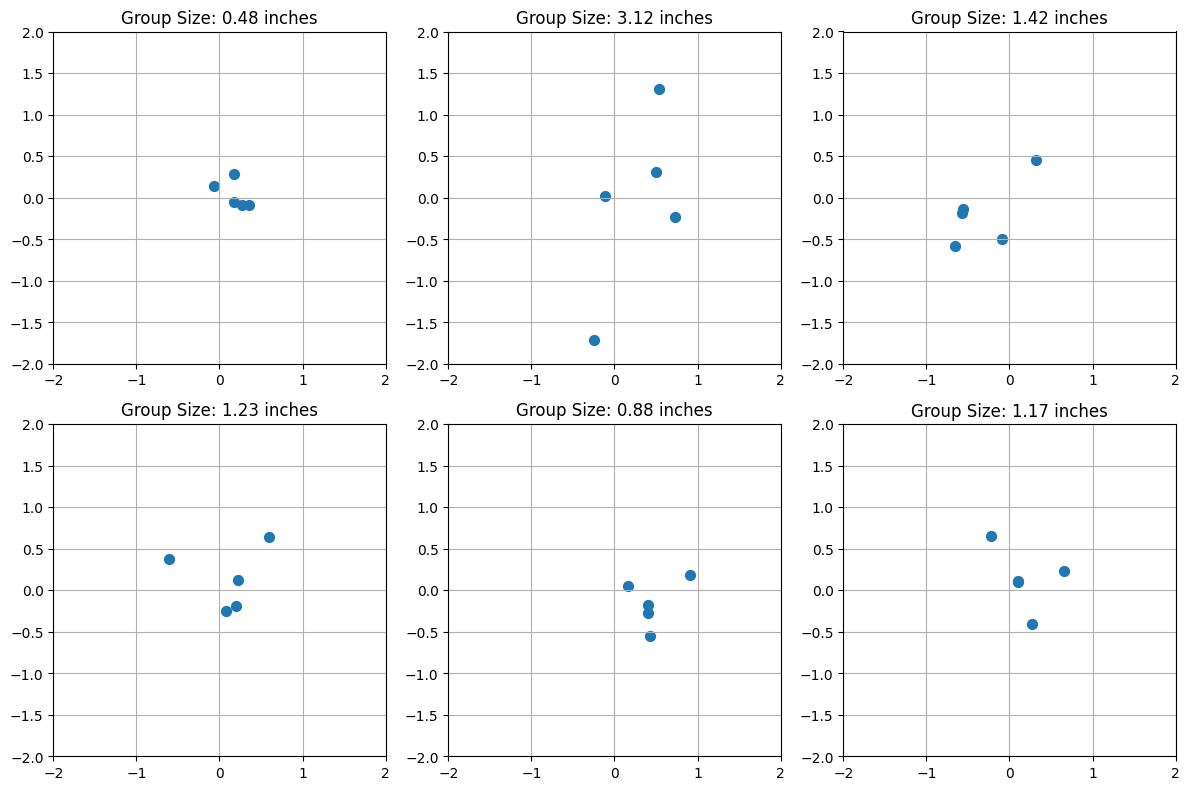

In [7]:
# Cell 6: Example: Show extreme and random 5-shot groups
# Find the smallest and largest group sizes
min_data = min(group_data_5, key=lambda x: x[0])
max_data = max(group_data_5, key=lambda x: x[0])

# Select 4 random groups
import random
random_groups = random.sample(group_data_5, 4)

# Combine: min, max, and 4 random
selected_groups = [min_data, max_data] + list(random_groups)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, (size, group_x, group_y) in enumerate(selected_groups):
    ax = axes.flat[i]
    ax.scatter(group_x, group_y, s=50)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.set_title(f'Group Size: {size:.2f} inches')
    ax.grid(True)

plt.tight_layout()
plt.show()

Our same true 1.5MOA rifle randomly produced groups that range from half MOA to over 3 MOA. Depending on the order you shot them, you might be very pleased or very displeased. Imagine if you were shooting 5 shot groups while varying powder charge looking for precision. You might think you have it but will get a very different apparent result the next time at the range.

**Interpretation:** These scatter plots display actual shot placements for six 5-shot groups, including the most extreme examples from 1000 simulations. The tightest group (smallest size) looks like exceptional accuracy, while the loosest appears poor. In practice, this variability means relying on a single group can lead to wrong conclusions about your rifle's true precision or load quality—always collect more data!

> **Key Takeaways**
> - Small sample sizes in reloading tests lead to unreliable results
> - Statistical significance requires adequate sample sizes
> - Common testing practices often fail to detect real differences
> - Simulation shows how luck can create false positives
> - 2/3 of 3-shot groups and over half of the 5-shot groups are lying to you
> - Even at 30-shot groups approximately half of them are lying to you, this is why it takes so many shots to validate claims regarding group sizes and SD
> - Proper testing methodology prevents chasing illusions

[Previous: 00_Welcome_and_Why_This_Matters.ipynb](00_Welcome_and_Why_This_Matters.ipynb) | [Next: 02_What_We_Actually_Mean_by_Consistency.ipynb](02_What_We_Actually_Mean_by_Consistency.ipynb)